### **PHASE 3: Exploratory Data Analysis**
**E-Commerece RFM Customer Segmentation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set up of visual style for all charts

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("Chart Settings Successfully Applied")

Chart Settings Successfully Applied


In [3]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Search for the file

import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'online_retail_cleans.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/RFM_Customer_Segmentation/Data/online_retail_cleans.csv


In [5]:
# Read the CSV

df = pd.read_csv("/content/drive/MyDrive/RFM_Customer_Segmentation/Data/online_retail_cleans.csv", encoding='Latin-1')

print("Data loaded successfully")

Data loaded successfully


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [7]:
# removing null values

df = df.dropna(subset=["CustomerID"])

In [8]:
df.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object
TotalPrice,float64




> **Month (Period) → used for math and grouping (pandas prefers this for calculations)**

> **YearMonth (String) → used for graphs and labels (charts need text, not Period objects)**



In [9]:
# Just an example


data = {
    "Original": ["2011-01-15 13:30:00", "2011-03-22 09:15:00"],
    "Month": ["2011-01", "2011-03"],
    "YearMonth": ["2011-01", "2011-03"],
    "DayOfWeek": ["Saturday", "Tuesday"],
    "Hour": [13, 9]
}

df_example = pd.DataFrame(data)
df_example

,Original,Month,YearMonth,DayOfWeek,Hour
0,2011-01-15 13:30:00,2011-01,2011-01,Saturday,13
1,2011-03-22 09:15:00,2011-03,2011-03,Tuesday,9


In [10]:
# Helping columns for time-based analysis

df["Month"] = df["InvoiceDate"].dt.to_period('M')
df["YearMonth"] = df["InvoiceDate"].dt.strftime("%Y-%m")
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

print("Clean Data Loaded")
print(f"Shape: {df.shape[0]:,} Rows -- {df.shape[1]} columns")

Clean Data Loaded
Shape: 392,692 Rows -- 13 columns


### **EDA 1: Revenue Overview**


In [11]:
# Revenue Overview

total_revenue = df["TotalPrice"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
average_order_value = total_revenue / total_orders


print(f"Total Renenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order: {average_order_value:,.2f}")

Total Renenue: 8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665
Average Order: 479.56


### **EDA 2: Country-Wise Revenue Analysis**

In [12]:
country_revenue = (
    df.groupby('Country')["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_revenue.columns = ["Country", "Revenue"]

country_revenue

,Country,Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


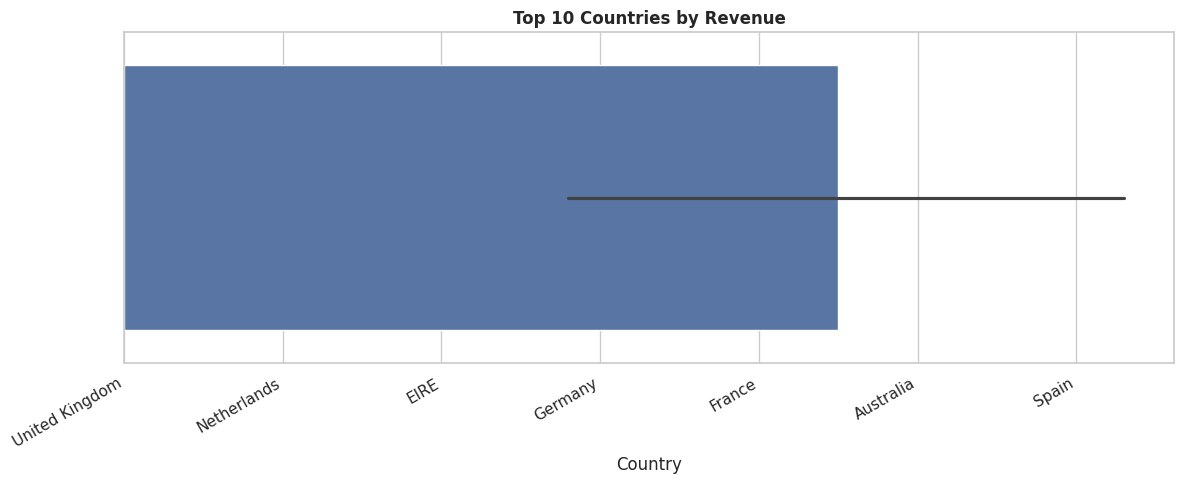

In [13]:
plt.figure(figsize=(12, 5))
sns.barplot(data=country_revenue, x="Country")
plt.title("Top 10 Countries by Revenue", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/content/01_country_revenue.png", dpi=150)
plt.show()

### **EDA 3: Monthly Revenue Trend**

In [14]:
monthly_revenue = (
    df.groupby("YearMonth")["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = ["Month", "Revenue"]
monthly_revenue


,Month,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


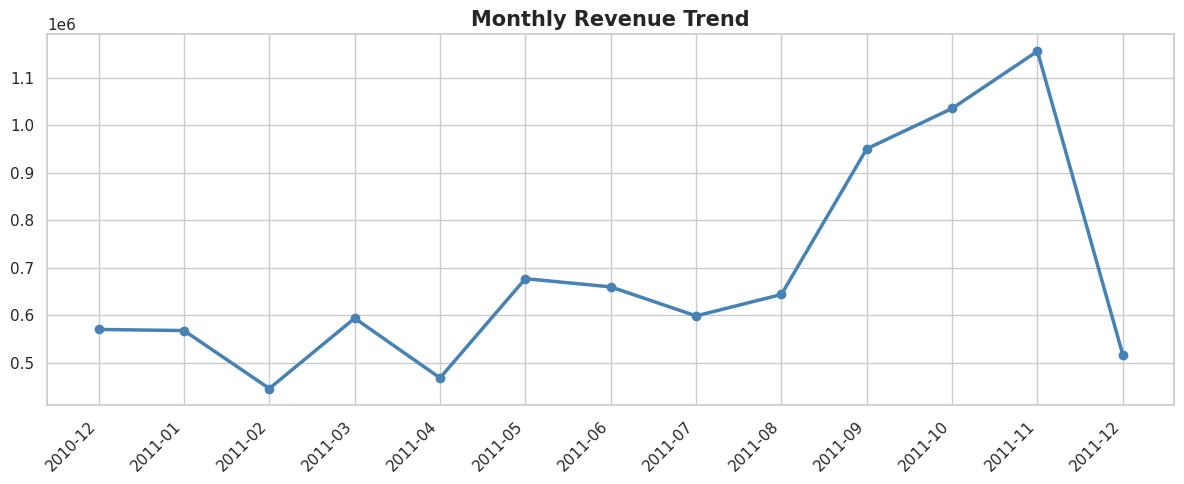

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"],
         marker="o", linewidth=2.5, color="steelblue")
plt.title("Monthly Revenue Trend", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/02_monthly_trend.png", dpi=150)
plt.show()


### **EDA 4: Top 10 Best-Selling Products**

In [16]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products.columns = ["Products", "Quantity Sold"]
top_products

,Products,Quantity Sold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3,JUMBO BAG RED RETROSPOT,46078
4,WHITE HANGING HEART T-LIGHT HOLDER,36706
5,ASSORTED COLOUR BIRD ORNAMENT,35263
6,PACK OF 72 RETROSPOT CAKE CASES,33670
7,POPCORN HOLDER,30919
8,RABBIT NIGHT LIGHT,27153
9,MINI PAINT SET VINTAGE,26076


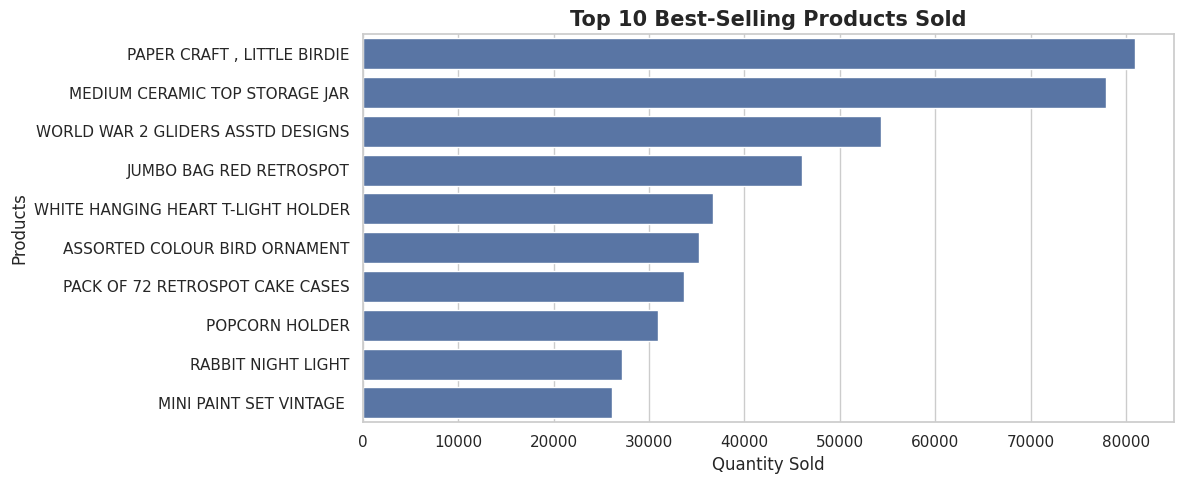

In [17]:
plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x="Quantity Sold", y="Products")
plt.title("Top 10 Best-Selling Products Sold", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/03_top_products.png", dpi=150)
plt.show()

### **EDA 5: Top 10 Custmers by Revenue**

In [29]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers.columns = ["CustomerID", "Revenue"]
top_customers

,CustomerID,Revenue
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


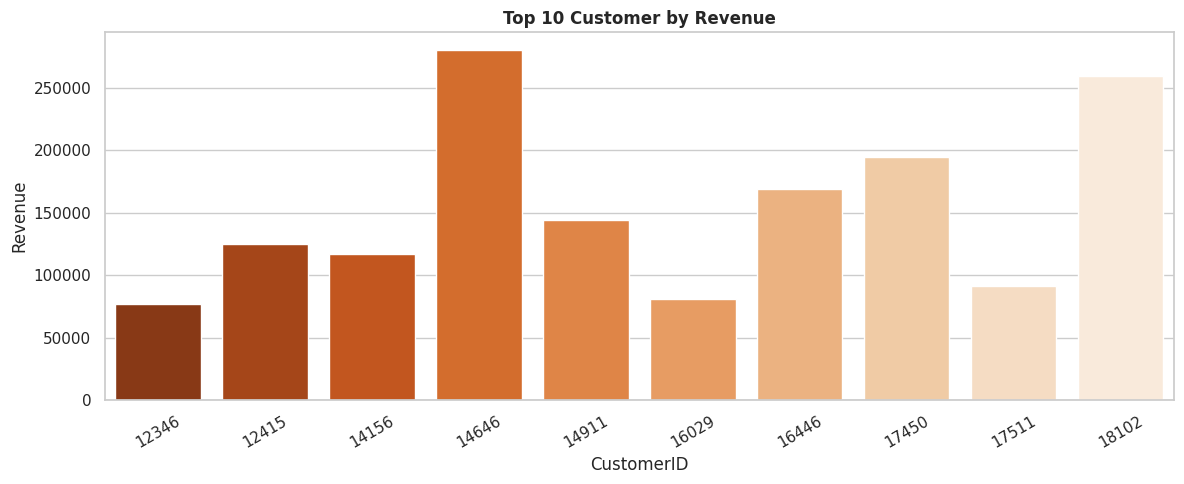

In [32]:
plt.figure(figsize=(12, 5))
sns.barplot(data=top_customers, x="CustomerID", y="Revenue", palette="Oranges_r")
plt.title("Top 10 Customer by Revenue", fontsize=12, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/content/04_top_customer.png", dpi=150)
plt.show()

### **EDA 6: Revenue by Day of Week**

In [47]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_revenue = (
    df.groupby("DayOfWeek")["TotalPrice"]
    .sum()
    .reindex(day_order)
    .sort_values(ascending=False)
    .reset_index()
)

day_revenue.columns = ["Day", "Revenue"]
day_revenue

,Day,Revenue
0,Thursday,1973015.730
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Friday,1483080.811
4,Monday,1363604.401
5,Sunday,785490.321
6,Saturday,NaN


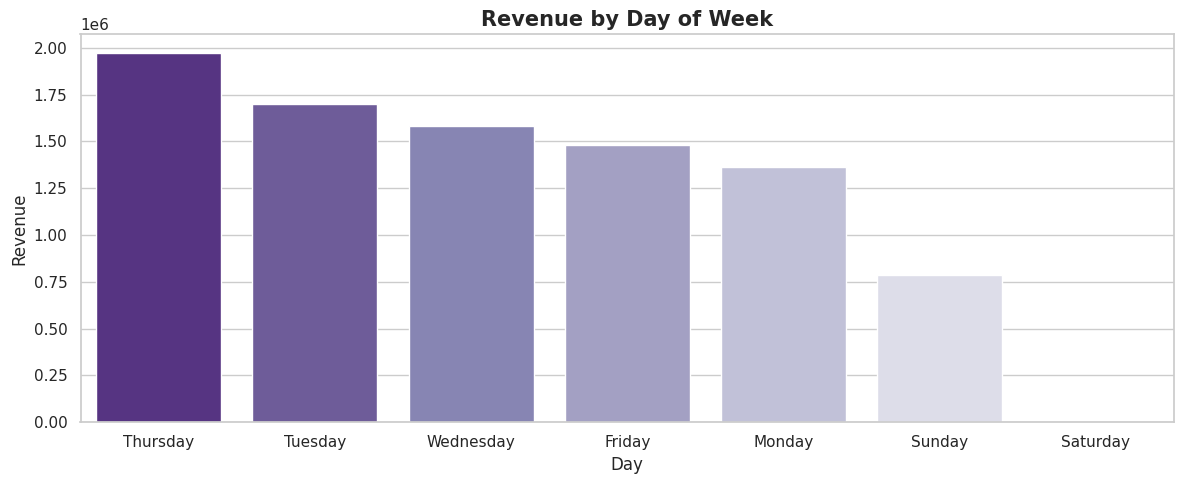

In [52]:
plt.figure(figsize=(12, 5))
sns.barplot(data=day_revenue, x="Day", y="Revenue", palette="Purples_r")
plt.title("Revenue by Day of Week", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/05_day_of_week.png", dpi=150)
plt.show()

### **EDA 7: Order Value Distribution**

In [56]:
order_revenue = df.groupby("InvoiceNo")["TotalPrice"].sum()
order_revenue_filtered = order_revenue[order_revenue <= 1000]

order_revenue_filtered

,TotalPrice
InvoiceNo,
536365,139.12
536366,22.20
536367,278.73
536368,70.05
536369,17.85
...,...
581583,124.60
581584,140.64
581585,329.05


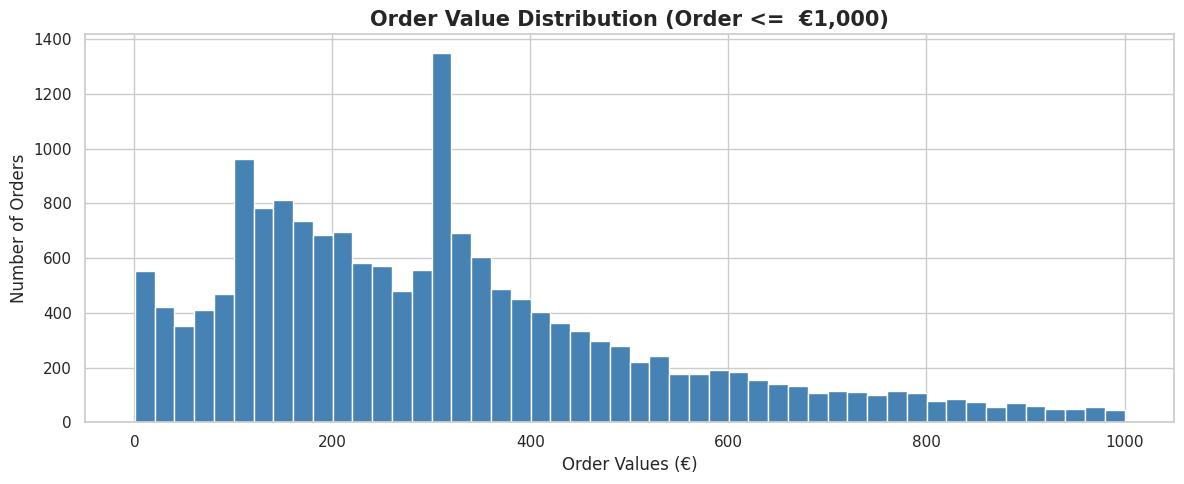

In [61]:
plt.figure(figsize=(12, 5))
plt.hist(order_revenue_filtered, bins=50, color="steelblue", edgecolor="white")
plt.title("Order Value Distribution (Order <=  €1,000)", fontsize=15, fontweight="bold")
plt.xlabel("Order Values (€)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("/content/06_order_distribution.png", dpi=150)
plt.show()

In [62]:
# Most customers spend between €100 to €350. Very few customers spend close to €1000.
order_revenue_filtered.describe()

,TotalPrice
count,17219.000000
mean,310.410457
std,211.156751
min,0.380000
25%,149.425000
50%,283.990000
75%,413.600000
max,1000.000000
